In [14]:
import pandas as pd
import numpy as np
import re




In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [16]:
df = pd.read_csv("fake_job_postings.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'fake_job_postings.csv'

In [ ]:
import pandas as pd
import numpy as np
import re
df = pd.read_csv("fake_job_postings.csv")

EmptyDataError: No columns to parse from file

In [ ]:
import pandas as pd

df = pd.read_csv("fake_job_postings.csv")

print(df.head())
print(df.shape)

EmptyDataError: No columns to parse from file

In [ ]:
import os
print(os.listdir())


['fake_job.ipynb', 'fake_job_postings copy.csv', 'fake_job_postings.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("fake_job_postings.csv")

print(df.head())
print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'fake_job_postings.csv'

In [ ]:
import pandas as pd

df = pd.read_csv("fake_job_postings copy.csv")

print(df.head())
print(df.shape)

   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         description  \
0  Foo

In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

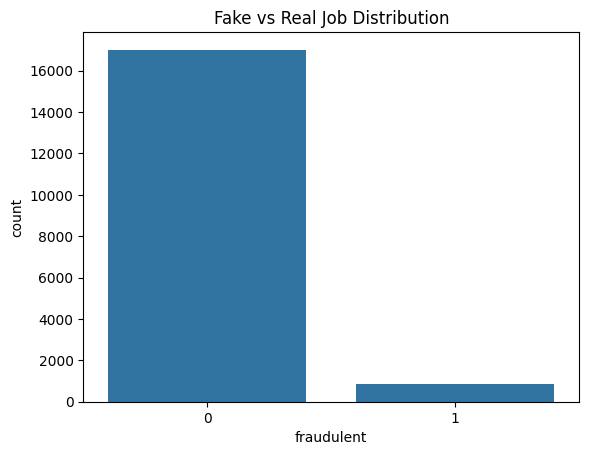

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['fraudulent'])
plt.title("Fake vs Real Job Distribution")
plt.show()

In [ ]:
df['text'] = (
    df['title'].fillna('') + " " +
    df['company_profile'].fillna('') + " " +
    df['description'].fillna('') + " " +
    df['requirements'].fillna('') + " " +
    df['benefits'].fillna('')
)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

NameError: name 'X_train_vec' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
y_pred = model.predict(X_test_vec)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9661633109619687


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=7000,
    ngram_range=(1,2)
)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3395    0]
 [ 121   60]]


In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [ ]:
def predict_job(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    result = model.predict(vec)
    
    if result[0] == 1:
        return "Fake Job"
    else:
        return "Real Job"

In [ ]:
print(predict_job("Earn money fast with no experience"))

NameError: name 'clean_text' is not defined

In [ ]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text

In [ ]:
def predict_job(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    result = model.predict(vec)
    
    if result[0] == 1:
        return "Fake Job ❌"
    else:
        return "Real Job ✅"

In [ ]:
print(predict_job("Earn money fast with no experience"))
print(predict_job("Software Engineer required with 3 years experience"))

NotFittedError: The TF-IDF vectorizer is not fitted

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [ ]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
print(predict_job("Earn money fast with no experience"))
print(predict_job("Software Engineer required with 3 years experience"))

Real Job ✅
Real Job ✅


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)   # 🔥 THIS LINE FITS IT
X_test_vec = vectorizer.transform(X_test)

NameError: name 'X_train' is not defined

In [ ]:
import pandas as pd
import re

df = pd.read_csv("fake_job_postings copy.csv")

In [ ]:
df['text'] = (
    df['title'].fillna('') + " " +
    df['company_profile'].fillna('') + " " +
    df['description'].fillna('') + " " +
    df['requirements'].fillna('') + " " +
    df['benefits'].fillna('')
)

In [ ]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text

df['text'] = df['text'].apply(clean_text)

In [ ]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [ ]:
print(df['fraudulent'].value_counts())

NameError: name 'df' is not defined

In [ ]:
df = pd.read_csv("fake_job_postings copy.csv")

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("fake_job_postings copy.csv")

In [ ]:
print(df['fraudulent'].value_counts())

fraudulent
0    17014
1      866
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample

df_majority = df[df.fraudulent == 0]
df_minority = df[df.fraudulent == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=7000,
    ngram_range=(1,2)
)

NameError: name 'TfidfVectorizer' is not defined

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=7000,
    ngram_range=(1,2)
)